In [1]:
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", DEVICE)

Используемое устройство: cpu


### Построение графа и матрицы смежности

In [2]:
G = nx.Graph()

G.add_edges_from([
    (0, 1),
    (0, 2),
    (1, 2),
    (1, 3),
    (1, 4),
    (2, 4),
    (3, 4),
    (4, 5),
    (4, 6),
    (5, 6),
    (5, 7),
])

A = np.array([
    [0, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 1, 0, 0, 0],
    [1, 1, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
], dtype=np.float32)

print(A)
print("\nФорма матрицы смежности A:", A.shape)

degrees = A.sum(axis=0)
print("\nСтепени узлов:", degrees)

[[0. 1. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1. 1.]
 [0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]]

Форма матрицы смежности A: (8, 8)

Степени узлов: [2. 4. 3. 2. 5. 3. 2. 1.]


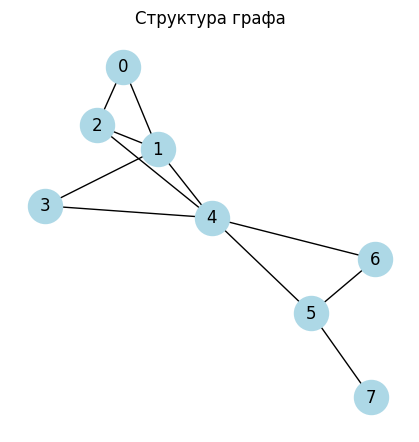

In [3]:
plt.figure(figsize=(4, 4))

pos = nx.spring_layout(G, seed=SEED)

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=600,
)

plt.title("Структура графа")
plt.show()

**Интерпретация:**  

Заданная форма матрицы смежности и полученные исходя из нее степени узлов соответствуют представленному изображению графа.

### Признаки узлов и агрегирование соседей

In [ ]:
num_nodes = A.shape[0]

deg = np.ones(num_nodes)
deg_norm = degrees / degrees.max() if degrees.max() else degrees

X = np.column_stack([
    deg,
    deg_norm,
]).astype(np.float32)

print(f"Форма X: {X.shape}")
print(f"\nПервые строки X: \n{X[:5]}")

AX = A @ X
print(f"\nФорма AX: {AX.shape}")
print(f"\nПервые строки AX (агрегированные признаки соседей): \n{AX[:5]}\n")

for i in range(num_nodes):
    neighbors = list(G.neighbors(i))
    if neighbors:
        print(f"Узел {i}: соседи {neighbors}, агрегированный признак = {AX[i]}")
    else:
        print(f"Для узла {i} нет соседей, агрегированный признак = {AX[i]}")

Форма X: (8, 2)

Первые строки X: 
[[1.  0.4]
 [1.  0.8]
 [1.  0.6]
 [1.  0.4]
 [1.  1. ]]

Форма AX: (8, 2)

Первые строки AX (агрегированные признаки соседей): 
[[2.        1.4000001]
 [4.        2.4      ]
 [3.        2.2      ]
 [2.        1.8      ]
 [5.        2.8000002]]

Узел 0: соседи [1, 2], агрегированный признак = [2.        1.4000001]
Узел 1: соседи [0, 2, 3, 4], агрегированный признак = [4.  2.4]
Узел 2: соседи [0, 1, 4], агрегированный признак = [3.  2.2]
Узел 3: соседи [1, 4], агрегированный признак = [2.  1.8]
Узел 4: соседи [1, 2, 3, 5, 6], агрегированный признак = [5.        2.8000002]
Узел 5: соседи [4, 6, 7], агрегированный признак = [3.  1.6]
Узел 6: соседи [4, 5], агрегированный признак = [2.  1.6]
Узел 7: соседи [5], агрегированный признак = [1.  0.6]


**Интерпретация:**  

Полученная матрица агрегированных признаков соответствует суммированию признаков по соседям.

### Нормализованный шаг GCN

In [10]:
def get_a_norm(A: np.ndarray) -> np.ndarray:
    """Нормализация матрицы смежности."""
    num_nodes = A.shape[0]
    I = np.eye(num_nodes, dtype=np.float32)
    A_hat = A + I
    D_hat = A_hat.sum(axis=1)
    D_inv_sqrt = np.diag(1 / np.sqrt(D_hat + 1e-8))
    return D_inv_sqrt @ A_hat @ D_inv_sqrt

In [13]:
A_norm = get_a_norm(A)
print("Форма A_norm:", A_norm.shape)
print("Форма X:", X.shape)

in_dim = X.shape[1]
out_dim = 4
W = np.random.randn(in_dim, out_dim).astype(np.float32) * 0.1
print("Форма W:", W.shape)

H = A_norm @ X @ W
print(f"\nФорма H: {H.shape}")
print(f"\nПервые строки H: \n{H[:5]}")

Форма A_norm: (8, 8)
Форма X: (8, 2)
Форма W: (2, 4)

Форма H: (8, 4)

Первые строки H: 
[[-0.01394806  0.01607576 -0.07646009 -0.19741549]
 [-0.01355086  0.01984951 -0.09731867 -0.2558949 ]
 [-0.00283626  0.01572792 -0.08337294 -0.2288779 ]
 [ 0.00057708  0.01300006 -0.071228   -0.19883838]
 [-0.01509405  0.02176939 -0.10654729 -0.27987704]]


**Интерпретация:**  

Размерности матриц согласованны: `A_norm(8, 8) @ X(8, 2) @ W(2, 4)`. Полученая матрица `H` содержит новые признаки вершин - собственные признаки + соседей. Для построения стабильных шагов графовой свертки следует добавлять петли и использовать нормализованную матрицу смежности.

### Узловая задача на синтетическом графе

In [24]:
G2 = nx.planted_partition_graph(l=2, k=15, p_in=0.5, p_out=0.05, seed=SEED)
A2 = nx.to_numpy_array(G2, dtype=np.float32)

num_nodes2 = A2.shape[0]
degrees2 = A2.sum(axis=1)

labels2 = np.zeros(30, dtype=np.int32)
labels2[15:] = 1

deg2 = np.ones(num_nodes2)
deg2_norm = degrees2 / degrees2.max() if degrees2.max() else degrees2
X2 = np.column_stack([
    deg2,
    deg2_norm,
]).astype(np.float32)

A2_norm = get_a_norm(A2)

W2 = np.random.randn(2, 2).astype(np.float32) * 0.1
H2 = A2_norm @ X2 @ W2

In [ ]:
def get_top_cols(embeddings):
    """Получить столбцы с максимальным количеством ненулевых значений."""
    nonzero_counts = (embeddings != 0).sum(axis=0)
    top_cols = np.argsort(nonzero_counts)[-2:][::-1]
    return top_cols

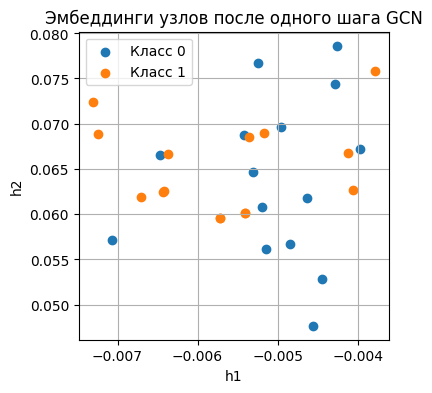

In [160]:
top_cols_one_step = get_top_cols(H2)
col1, col2 = top_cols_one_step[0], top_cols_one_step[1]

plt.figure(figsize=(4, 4))

for cls in (0, 1):
    class_0 = labels2 == cls
    plt.scatter(
        H2[class_0, col1],
        H2[class_0, col2],
        label=f"Класс {cls}",
    )

plt.title("Эмбеддинги узлов после одного шага GCN")
plt.xlabel("h1")
plt.ylabel("h2")
plt.legend()

plt.grid(True)
plt.show()

**Интерпретация:**  

Уже после одного шага графовой свертки можно сделать вывод о том, что алгоритм способен различить вершины двух классов, опираясь на их признаки и связи. После обучения, полученные эмбеддинги можно использовать для визуального анализа.

### Обучение простого GCN для классификации узлов

In [55]:
A2_norm_t = torch.from_numpy(A2_norm).float().to(DEVICE)
X2_t = torch.from_numpy(X2).float().to(DEVICE)
labels2_t = torch.from_numpy(labels2).long().to(DEVICE)

idx = np.arange(num_nodes2)
perm = np.random.permutation(idx)
weights = int(num_nodes2 * 0.7)

idx_train = torch.from_numpy(perm[:weights]).long().to(DEVICE)
idx_test = torch.from_numpy(perm[weights:]).long().to(DEVICE)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A_norm):
        x = A_norm @ x
        x = self.linear(x)
        return x

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.gcn2 = GCNLayer(hidden_dim, out_dim)

    def forward(self, x, A_norm):
        x = self.gcn1(x, A_norm)
        x = self.relu(x)
        x = self.gcn2(x, A_norm)
        return x

model_gcn = GCN(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS = 200
for epoch in range(EPOCHS):
    model_gcn.train()
    optimizer.zero_grad()

    logits = model_gcn(X2_t, A2_norm_t)
    loss = criterion(logits[idx_train], labels2_t[idx_train])

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 40 == 0:
        model_gcn.eval()
        with torch.no_grad():
            pred = model_gcn(X2_t, A2_norm_t)
            
            train_pred = pred[idx_train].argmax(dim=1)
            test_pred = pred[idx_test].argmax(dim=1)
            
            train_acc_gcn = accuracy_score(train_pred, labels2_t[idx_train])
            test_acc_gcn = accuracy_score(test_pred, labels2_t[idx_test])

        print(
            f"Эпоха {epoch+1:3d}, loss = {loss.item():.4f}, "
            f"train_acc = {train_acc_gcn:.2f}, test_acc = {test_acc_gcn:.2f}"
        )

Эпоха  40, loss = 0.6806, train_acc = 0.57, test_acc = 0.33
Эпоха  80, loss = 0.6720, train_acc = 0.57, test_acc = 0.33
Эпоха 120, loss = 0.6549, train_acc = 0.57, test_acc = 0.33
Эпоха 160, loss = 0.6263, train_acc = 0.62, test_acc = 0.56
Эпоха 200, loss = 0.5924, train_acc = 0.81, test_acc = 0.78


**Интерпретация:**  

К концу обучения модель значительно улучшила показатели точности (с `0.33` до `0.78` на тесте) с небольшим переобучением. GCN потребовалось около 160 эпох для эффективного распространения информации по графу, после чего точность резко выросла. Несмотря на небольшой граф и простые признаки (константа + степень), модель успешно разделила вершины по классам.

### Реализация и обучение упрощенного GraphSAGE

In [128]:
neighbors_list = list(list(G2.neighbors(i)) for i in range(num_nodes2))

class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.self_linear = nn.Linear(in_dim, out_dim)
        self.neigh_linear = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        neigh_agg = torch.zeros_like(x)

        N = x.shape[0]
        for i in range(N):
            neighbors = neighbors_list[i]
            if neighbors:
                neigh_features = x[neighbors]
                neigh_agg[i] = neigh_features.mean(dim=0)
            else:
                neigh_agg[i] = torch.zeros_like(x[i])

        out = self.self_linear(x) + self.neigh_linear(neigh_agg)
        return out

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.gsage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.gsage2 = GraphSAGELayer(hidden_dim, out_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.gsage1(x)
        x = self.relu(x)
        x = self.gsage2(x)
        return x

model_sage = GraphSAGE(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_sage = torch.optim.Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS_SAGE = 200
for epoch in range(EPOCHS_SAGE):
    model_sage.train()
    optimizer_sage.zero_grad()

    logits_sage = model_sage(X2_t)
    loss_sage = criterion(logits_sage[idx_train], labels2_t[idx_train])

    loss_sage.backward()
    optimizer_sage.step()

    if (epoch + 1) % 40 == 0:
        model_sage.eval()
        with torch.no_grad():
            pred_sage = model_sage(X2_t)
            
            train_pred = pred_sage[idx_train].argmax(dim=1)
            test_pred = pred_sage[idx_test].argmax(dim=1)
            
            train_acc_sage = accuracy_score(train_pred, labels2_t[idx_train])
            test_acc_sage = accuracy_score(test_pred, labels2_t[idx_test])

        print(
            f"[SAGE] Эпоха {epoch+1:3d}, loss = {loss_sage.item():.4f}, "
            f"train_acc = {train_acc_sage:.2f}, test_acc = {test_acc_sage:.2f}"
        )

[SAGE] Эпоха  40, loss = 0.6806, train_acc = 0.57, test_acc = 0.33
[SAGE] Эпоха  80, loss = 0.6510, train_acc = 0.57, test_acc = 0.33
[SAGE] Эпоха 120, loss = 0.6111, train_acc = 0.71, test_acc = 0.67
[SAGE] Эпоха 160, loss = 0.5679, train_acc = 0.76, test_acc = 0.33
[SAGE] Эпоха 200, loss = 0.5395, train_acc = 0.76, test_acc = 0.78


**Интерпретация:**  

Обе модели показали одинаковую финальную точность `0.78`, но GCN обучалась более стабильно. GraphSAGE продемонстрировала нестабильность обучения с резкими падениями точности. Несмотря на это, обе модели успешно решили задачу классификации узлов на небольшом графе.

### Сравнение эмбеддингов GCN и GraphSAGE

In [164]:
model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    h_gcn1 = model_gcn.gcn1(X2_t, A2_norm_t)
    h_gcn1 = F.relu(h_gcn1)

    h_sage1 = model_sage.gsage1(X2_t)
    h_sage1 = F.relu(h_sage1)

h_gcn_np = h_gcn1.numpy()
h_sage_np = h_sage1.numpy()

In [165]:
top_cols_gcn = get_top_cols(h_gcn_np)
col1_gcn, col2_gcn = top_cols_gcn[0], top_cols_gcn[1]

top_cols_sage = get_top_cols(h_sage_np)
col1_sage, col2_sage = top_cols_sage[0], top_cols_sage[1]

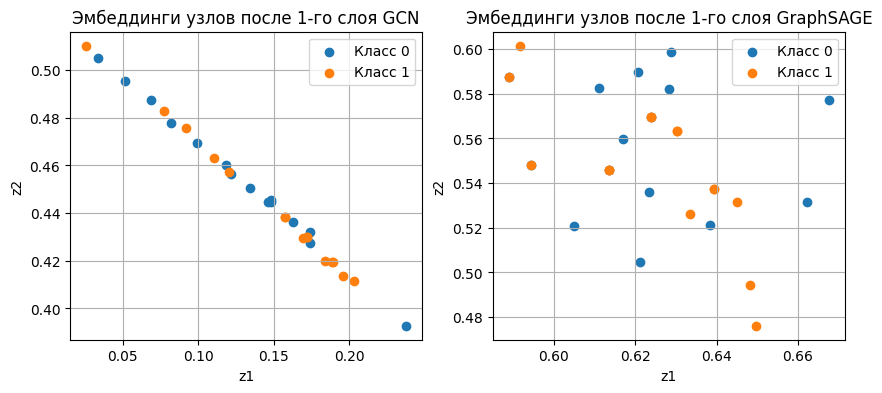

In [166]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)

for cls in (0, 1):
    val = labels2 == cls
    plt.scatter(
        h_gcn_np[val, col1_gcn],
        h_gcn_np[val, col2_gcn],
        label=f"Класс {cls}",
    )

plt.title("Эмбеддинги узлов после 1-го слоя GCN")
plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

for cls in (0, 1):
    val = labels2 == cls
    plt.scatter(
        h_sage_np[val, col1_sage],
        h_sage_np[val, col2_sage],
        label=f"Класс {cls}",
    )

plt.title("Эмбеддинги узлов после 1-го слоя GraphSAGE")
plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()

plt.grid(True)
plt.show()

### Graph-level классификация с pooling

In [208]:
num_graphs_per_class = 400
num_nodes_min, num_nodes_max = 10, 15

graphs = []
labels_graph = []

for cls in [0, 1]:
    for _ in range(num_graphs_per_class):
        n = np.random.randint(num_nodes_min, num_nodes_max + 1)
        p = 0.5 if cls else 0.2
        Gg = nx.erdos_renyi_graph(n=n, p=p, seed=SEED)

        if not nx.is_connected(Gg):
            Gg = G.subgraph(max(nx.connected_components(G), key=len)).copy()

        graphs.append(Gg)
        labels_graph.append(cls)

labels_graph = np.array(labels_graph, dtype=np.int64)


def graph_embedding_gcn_like(Gg):
    """
    Вычисляет эмбеддинг графа через один нормализованный шаг GCN и mean pooling.

    Возвращает:
        h_graph: np.ndarray формы (out_dim,)
    """
    A = nx.to_numpy_array(Gg, dtype=np.float32)
    degrees = np.array([deg for _, deg in Gg.degree()], dtype=np.float32)

    X = np.column_stack([
        np.ones_like(degrees),
        degrees / degrees.max() if degrees.max() else degrees,
    ])

    A_norm = get_a_norm(A)

    W = np.random.randn(2, 4).astype(np.float32) * 0.1

    H = A_norm @ X @ W
    H = np.maximum(0, H)

    return H.mean(axis=0)

X_graph = np.stack([graph_embedding_gcn_like(Gg) for Gg in graphs], axis=0)
print("Форма X_graph:", X_graph.shape)

y_graph = np.array(labels_graph, dtype=np.int64)
print("Форма y_graph:", y_graph.shape)

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_graph, y_graph,
    test_size=0.3,
    stratify=labels_graph,
)

class GraphMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

model_graph = GraphMLP(in_dim=4, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_graph = torch.optim.Adam(model_graph.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

X_train_t = torch.Tensor(X_train_g).float()
X_test_t = torch.Tensor(X_test_g).float()
y_train_t = torch.Tensor(y_train_g).long()
y_test_t = torch.Tensor(y_test_g).long()

EPOCHS_GRAPH = 200
for epoch in range(EPOCHS_GRAPH):
    model_graph.train()
    optimizer_graph.zero_grad()

    logits_g = model_graph(X_train_t)
    loss_g = criterion(logits_g, y_train_t)

    loss_g.backward()
    optimizer_graph.step()

    if (epoch + 1) % 50 == 0:
        model_graph.eval()

        with torch.no_grad():
            pred_train = model_graph(X_train_t)
            pred_test = model_graph(X_test_t)
            
            test_acc_g = accuracy_score(pred_train.argmax(dim=1), y_train_t)          
            train_acc_g = accuracy_score(pred_test.argmax(dim=1), y_test_t)

        print(
            f"Эпоха {epoch+1:3d}, loss = {loss_g.item():.4f}, "
            f"train_acc = {train_acc_g:.2f}, test_acc = {test_acc_g:.2f}"
        )

Форма X_graph: (800, 4)
Форма y_graph: (800,)
Эпоха  50, loss = 0.6916, train_acc = 0.47, test_acc = 0.53
Эпоха 100, loss = 0.6897, train_acc = 0.55, test_acc = 0.54
Эпоха 150, loss = 0.6867, train_acc = 0.55, test_acc = 0.54
Эпоха 200, loss = 0.6831, train_acc = 0.56, test_acc = 0.56


**Интерпретация:**  

Модель GraphMLP на случайных GCN-эмбеддингах не смогла обучиться: точность оказалась почти на уровне случайного угадывания - `0.56`.

### Итоговое сравнение GCN, GraphSAGE и graph-level модели

In [209]:
model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    logits_gcn = model_gcn(X2_t, A2_norm_t)
    train_pred = pred[idx_train].argmax(dim=1)
    test_pred = pred[idx_test].argmax(dim=1)

    train_acc_gcn = accuracy_score(train_pred, labels2_t[idx_train])
    test_acc_gcn = accuracy_score(test_pred, labels2_t[idx_test])

    logits_sage = model_sage(X2_t)
    train_pred = logits_sage[idx_train].argmax(dim=1)
    test_pred = logits_sage[idx_test].argmax(dim=1)
    
    train_acc_sage = accuracy_score(train_pred, labels2_t[idx_train])
    test_acc_sage = accuracy_score(test_pred, labels2_t[idx_test])

model_graph.eval()
with torch.no_grad():
    pred_test = model_graph(X_test_t)
    pred_train = model_graph(X_train_t)

    train_acc_graph = accuracy_score(pred_train.argmax(dim=1), y_train_t)
    test_acc_graph = accuracy_score(pred_test.argmax(dim=1), y_test_t)

print("=" * 60)
print(f"{'Модель':<25} {'train_acc':>10} {'test_acc':>10}")
print("=" * 60)
print(f"{'GCN (узловая)':<25} {train_acc_gcn:>10.3f} {test_acc_gcn:>10.3f}")
print(f"{'GraphSAGE (узловая)':<25} {train_acc_sage:>10.3f} {test_acc_sage:>10.3f}")
print(f"{'Graph MLP + pooling':<25} {train_acc_graph:>10.3f} {test_acc_graph:>10.3f}")
print("=" * 60)


Модель                     train_acc   test_acc
GCN (узловая)                  0.810      0.778
GraphSAGE (узловая)            0.762      0.778
Graph MLP + pooling            0.561      0.562


**Интерпретация:**  

`GCN` и `GraphSAGE` модели достигли сопоставимой точности в `0.778`, но `GCN` обучается стабильнее благодаря нормализации матрицы смежности. `GraphSAGE` с простым усреднением соседей без нормализации показывает нестабильное поведение, хотя финальный результат не уступает `GCN`. В то же время, `GraphMLP` не обучилась (точность на уровне случайной). Одной из причин является использование случайных весов при генерации эмбеддингов графов - фиксированные случайные признаки не несут информации о классе.